In [96]:
import numpy as np
import matplotlib.pyplot as plt

In [97]:
pi0=np.array([.2, .8])
A0=np.array([[.5, .5], [.4, .6]])
B1 = np.array([.5, .4, .1])
B2 = np.array([.2, .4, .4])
B0 = np.array([B1, B2])


### Bad algorithm: $O(N^T)$ where N is the number of states and T is the length of the observation sequence

In [98]:
def probStates(start, A, B, obs):
    Pvals = np.zeros((2, 2, 2))
    states = []
    for i in range(2):
        for j in range(2):
            for k in range(2):
                states.append((i, j, k))
                Pvals[i, j, k] = start[i]*A[i, j]*A[j, k]*B[i, obs[0]]*B[j, obs[1]]*B[k, obs[2]]
    Pvals = Pvals.flatten()
    Pvals /= np.sum(Pvals)
    print(Pvals[np.argmax(Pvals)])
    print(states[np.argmax(Pvals)])
    plt.bar(np.arange(8), Pvals)
    plt.xticks(np.arange(8), states, rotation=45)
    plt.xlabel("State sequence")
    plt.ylabel("Probability")
    plt.title("Probability of state sequences given the observation")
    plt.show()

0.4481478888033052
(1, 0, 1)


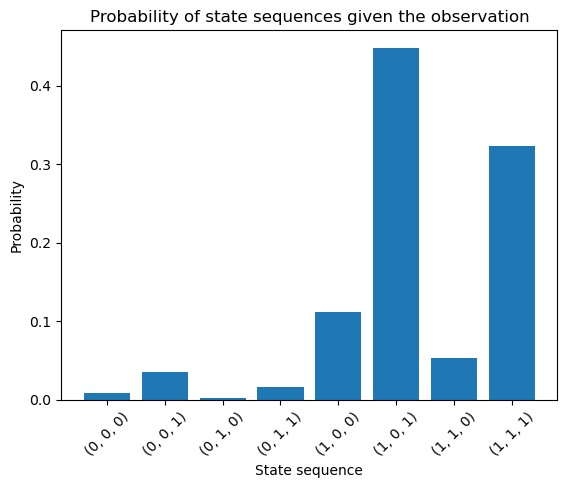

In [99]:
probStates(pi0, A0, B0, np.array([2, 0, 2]))

In [100]:
# for n in range(0,3):
#     for m in range(0,3):
#         for l in range(0,3):
#             obs = np.array([n, m, l])
#             print(f"Observation: {obs+1}")
#             probStates(pi0, A0, B0, obs)

### The Forward algorithm: $O(N^2T)$ where N is the number of states and T is the length of the observation sequence

In [101]:
def forward(start, A, B, obs):
    N = len(start)
    T = len(obs)

    forward_vals = np.zeros((N, T))

    # Initialization
    for i in range(N):
        forward_vals[i, 0] = start[i] * B[i, obs[0]]

    # Recursion
    for t in range(1, T):
        for j in range(N):
            forward_vals[j, t] = np.sum(forward_vals[:, t-1] * A[:, j]) * B[j, obs[t]]

    # Total probability of observation sequence
    prob = np.sum(forward_vals[:, -1])

    return forward_vals, prob

def viterbi(start, A, B, obs):
    N = len(start)
    T = len(obs)

    viterbi = np.zeros((N, T))
    backpointer = np.zeros((N, T), dtype=int)

    # Initialization
    for i in range(N):
        viterbi[i, 0] = start[i] * B[i, obs[0]]
        backpointer[i, 0] = 0

    # Recursion
    for t in range(1, T):
        for j in range(N):
            seq_probs = viterbi[:, t-1] * A[:, j]
            backpointer[j, t] = np.argmax(seq_probs)
            viterbi[j, t] = np.max(seq_probs) * B[j, obs[t]]

    # Backtracking
    states = np.zeros(T, dtype=int)
    states[T-1] = np.argmax(viterbi[:, T-1])
    best_prob = np.max(viterbi[:, T-1])

    for t in range(T-2, -1, -1):
        states[t] = backpointer[states[t+1], t+1]
    return states, best_prob

# Forward prob er sandsynlighed for en givens sekvens P(O), mens Viterbi finder den mest sandsynlige sekvens af skjulte tilstande Q* givet en observation O, og beregner sandsynligheden for denne sekvens P(Q*, O). 
# Posterior sandsynlighed for Viterbi sekvensen er P(Q* | O) = P(Q*, O) / P(O), dette er sandsynligheden for at den mest sandsynlige sekvens af skjulte tilstande Q* er korrekt givet observationen O.

In [102]:
N = np.arange(25)
N = N.reshape(5, 5)
print(N)
print(np.sum(N, axis=1, keepdims=True))

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]
[[ 10]
 [ 35]
 [ 60]
 [ 85]
 [110]]


In [103]:
def baum_welch(obs_seq, N, M, max_iters=100, tol=1e-4):
    """
    obs_seq: list of observation indices (0..M-1)
    N: number of hidden states
    M: number of observation symbols (vocabulary size)
    max_iters: max iterations
    tol: convergence tolerance
    
    Returns:
        A: learned transition matrix (N x N)
        B: learned emission matrix (N x M)
        pi: learned initial probabilities (N,)
    """
    T = len(obs_seq)
    
    # --- Initialize A, B, pi randomly ---
    # np.random.seed(42)
    A = np.random.rand(N, N)
    A /= A.sum(axis=1, keepdims=True)
    # Axis 1 is along the rows, so this normalizes each row to sum to 1, making A a valid transition matrix. Keepdims=True keeps the dimensions of the array, so the result is still a 2D array with shape (N, N).
    
    B = np.random.rand(N, M)
    B /= B.sum(axis=1, keepdims=True)
    
    pi = np.random.rand(N)
    pi /= pi.sum()
    
    for iteration in range(max_iters):
        # --- Forward pass ---
        alpha = np.zeros((T, N))
        alpha[0, :] = pi * B[:, obs_seq[0]]
        for t in range(1, T):
            for j in range(N):
                alpha[t, j] = np.sum(alpha[t-1, :] * A[:, j]) * B[j, obs_seq[t]]
        
        # --- Backward pass ---
        beta = np.zeros((T, N))
        beta[T-1, :] = 1
        for t in reversed(range(T-1)):
            for i in range(N):
                beta[t, i] = np.sum(A[i, :] * B[:, obs_seq[t+1]] * beta[t+1, :])
        
        # --- Compute gamma and xi ---
        gamma = (alpha * beta)
        gamma /= gamma.sum(axis=1, keepdims=True)
        
        xi = np.zeros((T-1, N, N))
        for t in range(T-1):
            denom = np.sum(alpha[t, :, None] * A * B[:, obs_seq[t+1]] * beta[t+1, :])
            for i in range(N):
                xi[t, i, :] = alpha[t, i] * A[i, :] * B[:, obs_seq[t+1]] * beta[t+1, :]
            xi[t, :, :] /= denom
        
        # --- Update parameters ---
        pi_new = gamma[0, :]
        A_new = np.sum(xi, axis=0) / np.sum(gamma[:-1, :], axis=0)[:, None]
        
        B_new = np.zeros_like(B)
        for j in range(N):
            for k in range(M):
                mask = np.array(obs_seq) == k
                B_new[j, k] = np.sum(gamma[mask, j])
            B_new[j, :] /= np.sum(gamma[:, j])
        
        # --- Check convergence ---
        if np.max(np.abs(A_new - A)) < tol and np.max(np.abs(B_new - B)) < tol:
            break
        
        A, B, pi = A_new, B_new, pi_new
    
    return A, B, pi

In [104]:
def baum_welch_multiple(sequences, N, V, max_iters=100, tol=1e-4):
    """
    sequences: list of observation sequences (each a list of integers 0..V-1)
    N: number of hidden states
    V: number of observation symbols
    max_iters: maximum EM iterations
    tol: convergence tolerance
    
    Returns:
        A: transition matrix (N x N)
        B: emission matrix (N x V)
        pi: initial probabilities (N,)
    """
    
    # --- Initialize parameters ---
    A = np.random.rand(N, N)
    A /= A.sum(axis=1, keepdims=True)
    
    B = np.random.rand(N, V)
    B /= B.sum(axis=1, keepdims=True)
    
    pi = np.ones(N) / N  # non-extreme initialization
    
    for iteration in range(max_iters):
        # Accumulators
        pi_accum = np.zeros(N)
        A_accum_num = np.zeros((N, N))
        A_accum_den = np.zeros(N)
        B_accum_num = np.zeros((N, V))
        B_accum_den = np.zeros(N)
        
        for obs_seq in sequences:
            T = len(obs_seq)
            
            # --- Forward ---
            alpha = np.zeros((T, N))
            alpha[0, :] = pi * B[:, obs_seq[0]]
            for t in range(1, T):
                for j in range(N):
                    alpha[t, j] = np.sum(alpha[t-1, :] * A[:, j]) * B[j, obs_seq[t]]
            
            # --- Backward ---
            beta = np.zeros((T, N))
            beta[T-1, :] = 1
            for t in reversed(range(T-1)):
                for i in range(N):
                    beta[t, i] = np.sum(A[i, :] * B[:, obs_seq[t+1]] * beta[t+1, :])
            
            # --- Gamma and Xi ---
            gamma = alpha * beta
            gamma /= gamma.sum(axis=1, keepdims=True)
            
            xi = np.zeros((T-1, N, N))
            for t in range(T-1):
                denom = np.sum(alpha[t, :, None] * A * B[:, obs_seq[t+1]] * beta[t+1, :])
                xi[t, :, :] = alpha[t, :, None] * A * B[:, obs_seq[t+1]] * beta[t+1, :] / denom
            
            # --- Accumulate for global updates ---
            pi_accum += gamma[0, :]
            A_accum_num += xi.sum(axis=0)
            A_accum_den += gamma[:-1, :].sum(axis=0)
            
            for j in range(N):
                for k in range(V):
                    B_accum_num[j, k] += gamma[np.array(obs_seq) == k, j].sum()
                B_accum_den[j] += gamma[:, j].sum()
        
        # --- Update parameters ---
        pi_new = pi_accum / pi_accum.sum()
        A_new = A_accum_num / A_accum_den[:, None]
        B_new = B_accum_num / B_accum_den[:, None]
        
        # --- Convergence check ---
        if (np.max(np.abs(pi_new - pi)) < tol and
            np.max(np.abs(A_new - A)) < tol and
            np.max(np.abs(B_new - B)) < tol):
            break
        
        pi, A, B = pi_new, A_new, B_new
    
    return A, B, pi

In [105]:
def stateTranslater(state, B):
    stateMeans = np.dot(B, np.arange(B.shape[1])) # We assume that the state with the lower expected number of ice creams eaten is 'cold'
    if stateMeans[0] < stateMeans[1]:
        return ['cold' if s == 0 else 'hot' for s in state] 
    else:
        return ['hot' if s == 0 else 'cold' for s in state]

In [117]:
# Observation sequence (encoded as integers)
obs_seq1 = [2, 2, 2, 0, 0, 0, 1, 1, 1, 2, 2, 2] 
obs_seq2 = [1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1]
obs_seqs = [obs_seq1, obs_seq2]

# print("Observation sequence:", obs_seq)
V = max(max(seq) for seq in obs_seqs)+1  # number of observation symbols
Q = 2  # number of hidden states
np.random.seed(42)  # for reproducibility
A_learned, B_learned, pi_learned = baum_welch_multiple(obs_seqs, Q, V)

print("Learned Transition Matrix A:")
print(np.round(A_learned, 2))
print("\nLearned Emission Matrix B:")
print(np.round(B_learned, 2))
print("\nLearned Initial Probabilities pi:")
print(np.round(pi_learned, 2))


Learned Transition Matrix A:
[[0. 1.]
 [1. 0.]]

Learned Emission Matrix B:
[[0.08 0.67 0.25]
 [0.17 0.33 0.5 ]]

Learned Initial Probabilities pi:
[1. 0.]


In [118]:
seq = [2, 2, 2, 1, 1, 1]  # Combine all sequences into one for testing

alpha, prob = forward(pi_learned, A_learned, B_learned, seq)
# print("Forward table:\n", alpha)
print("P(observations) =", prob)

viterbi_states, viterbi_prob = viterbi(pi_learned, A_learned, B_learned, seq)
print("Viterbi best state sequence:", viterbi_states)
# print("Viterbi best sequence probability:", viterbi_prob)

posterior = viterbi_prob / prob
print("Posterior probability of Viterbi sequence:", posterior)
print('The most likely temperature of the days were:', stateTranslater(viterbi_states, B_learned))

P(observations) = 0.002316794228978631
Viterbi best state sequence: [0 1 0 1 0 1]
Posterior probability of Viterbi sequence: 0.9980099572610795
The most likely temperature of the days were: ['cold', 'hot', 'cold', 'hot', 'cold', 'hot']
